## Imports

In [116]:
# ============================================================
# Energy Customer Churn — PowerCo Dataset (your files)
# Files:
#   ml_case_training_data.csv    — client features
#   ml_case_training_hist_data.csv — price history
#   ml_case_training_output.csv  — churn labels
# ============================================================

import multiprocessing
multiprocessing.set_start_method('fork', force=True)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, RocCurveDisplay
)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import shap

## Load Data

In [117]:
# ============================================================
# 1. LOAD DATA
# ============================================================

import os
BASE_PATH = os.path.expanduser('~/Downloads/archive-2/')

client = pd.read_csv(f'{BASE_PATH}ml_case_training_data.csv')
hist   = pd.read_csv(f'{BASE_PATH}ml_case_training_hist_data.csv')
output = pd.read_csv(f'{BASE_PATH}ml_case_training_output.csv')

summary = pd.DataFrame({
    'File': ['client', 'history', 'output'],
    'Rows': [client.shape[0], hist.shape[0], output.shape[0]],
    'Columns': [client.shape[1], hist.shape[1], output.shape[1]]
})

summary.style.set_caption('Dataset Summary') \
    .set_properties(**{'text-align': 'center'}) \
    .hide(axis='index')

File,Rows,Columns
client,16096,32
history,193002,8
output,16096,2


### Churn Rate Chart

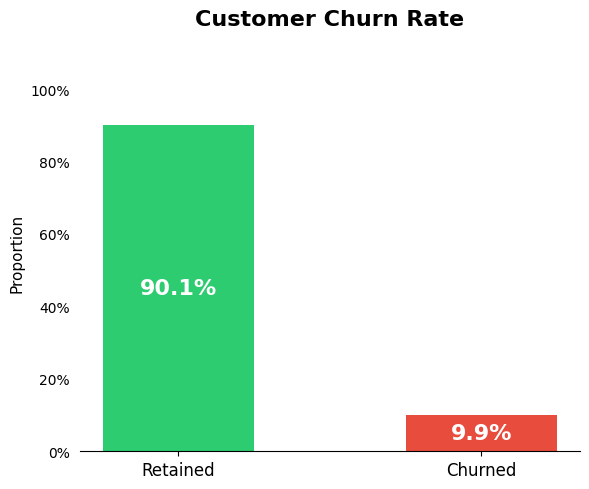

In [118]:
# ============================================================
# 2. EXPLORATORY DATA ANALYSIS
# ============================================================

df_eda = client.merge(output, on='id', how='left')

# --- 2.1 Churn Rate ---
churn_rate = df_eda['churn'].value_counts(normalize=True)

fig, ax = plt.subplots(figsize=(6, 5))
colors = ['#2ECC71', '#E74C3C']
bars = ax.bar(['Retained', 'Churned'], churn_rate.values, color=colors,
              width=0.5, edgecolor='none')

for bar, v in zip(bars, churn_rate.values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() / 2,
            f'{v:.1%}', ha='center', va='center',
            fontsize=16, fontweight='bold', color='white')

ax.set_title('Customer Churn Rate', fontsize=16, fontweight='bold', pad=20)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Proportion', fontsize=11)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.yaxis.set_ticks_position('none')
ax.tick_params(axis='x', labelsize=12)
ax.set_anchor('C')
plt.tight_layout()
plt.show()

### Categorical Features Chart

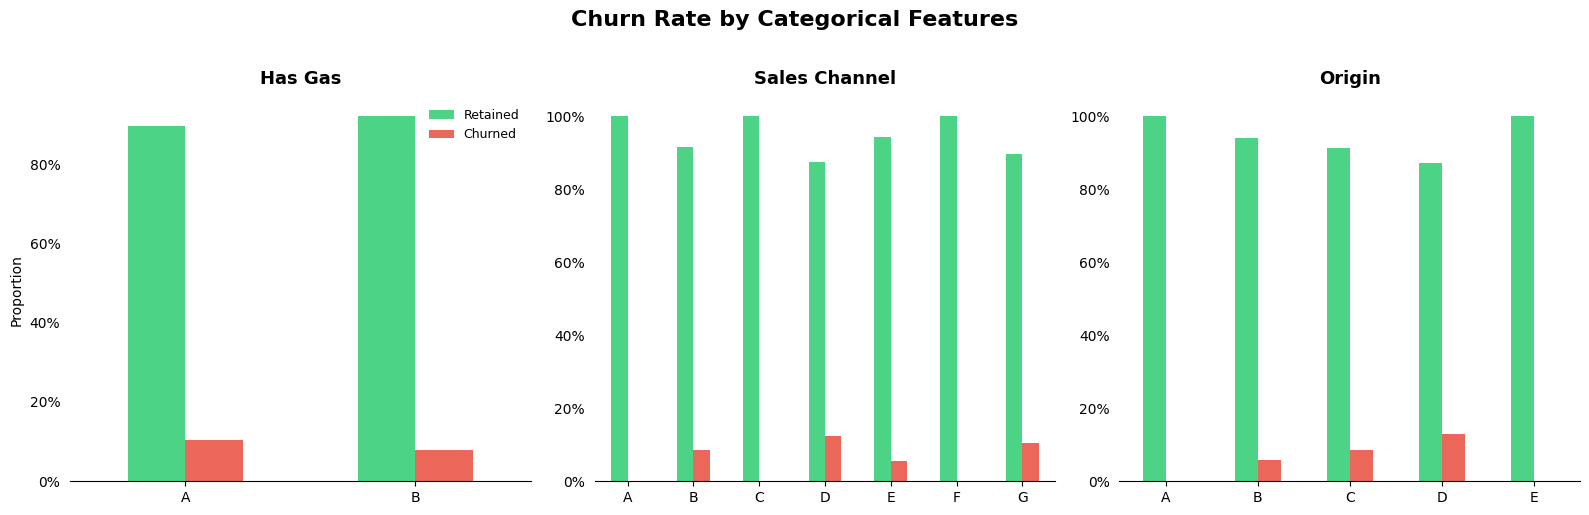

In [119]:
# --- 2.2 Categorical Features vs Churn ---
cat_cols = ['has_gas', 'channel_sales', 'origin_up']
titles   = ['Has Gas', 'Sales Channel', 'Origin']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Churn Rate by Categorical Features', fontsize=16, fontweight='bold', y=1.02)

for ax, col, title in zip(axes, cat_cols, titles):
    ct = pd.crosstab(df_eda[col], df_eda['churn'], normalize='index')
    ct.columns = ['Retained', 'Churned']

    # Shorten hashed labels to A, B, C...
    short_labels = [chr(65 + i) for i in range(len(ct))]
    ct.index = short_labels

    ct.plot(kind='bar', ax=ax, color=['#2ECC71', '#E74C3C'],
            edgecolor='none', alpha=0.85, legend=(col == 'has_gas'))

    ax.set_title(title, fontsize=13, fontweight='bold', pad=10)
    ax.set_xlabel('')
    ax.set_ylabel('Proportion' if col == 'has_gas' else '')
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
    ax.tick_params(axis='x', rotation=0, labelsize=10)
    ax.spines[['top', 'right', 'left']].set_visible(False)
    ax.yaxis.set_ticks_position('none')

    if col == 'has_gas':
        ax.legend(fontsize=9, frameon=False)

plt.tight_layout()
plt.show()

## Consumptions Distribution Chart

In [ ]:
# --- 2.3 Consumption Distributions ---

num_cols = ['cons_12m', 'cons_last_month', 'forecast_cons_12m', 'net_margin', 'imp_cons']
titles   = ['12M Consumption', 'Last Month Usage', 'Forecasted 12M', 'Net Margin', 'Current Consumption']

fig, axes = plt.subplots(1, len(num_cols), figsize=(20, 4))
fig.suptitle('Consumption Distribution: Churned vs Retained', fontsize=16, fontweight='bold', y=1.02)

for ax, col, title in zip(axes, num_cols, titles):
    churned     = df_eda[df_eda['churn'] == 1][col].dropna()
    not_churned = df_eda[df_eda['churn'] == 0][col].dropna()

    ax.hist(not_churned.clip(upper=not_churned.quantile(0.99)),
            bins=40, alpha=0.6, color='#2ECC71', label='Retained', density=True)
    ax.hist(churned.clip(upper=churned.quantile(0.99)),
            bins=40, alpha=0.6, color='#E74C3C', label='Churned', density=True)

    ax.set_title(title, fontsize=11, fontweight='bold', pad=10)
    ax.set_xlabel('')
    ax.set_ylabel('Density' if col == num_cols[0] else '')
    ax.spines[['top', 'right', 'left']].set_visible(False)
    ax.yaxis.set_ticks_position('none')
    ax.tick_params(axis='both', labelsize=8)

    if col == num_cols[0]:
        ax.legend(fontsize=9, frameon=False)

plt.tight_layout()
plt.show()

## Tenure Analysis Chart

In [ ]:
# --- 2.4 Tenure Analysis ---

df_eda['date_activ'] = pd.to_datetime(df_eda['date_activ'])
df_eda['date_end']   = pd.to_datetime(df_eda['date_end'])
df_eda['tenure_months'] = (
    (df_eda['date_end'] - df_eda['date_activ']).dt.days / 30
).round().clip(lower=0)

bins   = [0, 12, 24, 48, 72, df_eda['tenure_months'].max() + 1]
labels = ['Less than 1 year', '1 – 2 years', '2 – 4 years', '4 – 6 years', 'Over 6 years']
df_eda['tenure_group'] = pd.cut(df_eda['tenure_months'], bins=bins, labels=labels)

grouped = df_eda.groupby('tenure_group')['churn'].mean()

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#E74C3C' if v == grouped.max() else '#3498DB' for v in grouped.values]
bars = ax.bar(grouped.index, grouped.values, color=colors, edgecolor='none', alpha=0.85, width=0.5)

for bar, v in zip(bars, grouped.values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.003,
            f'{v:.1%}', ha='center', fontsize=10, fontweight='bold',
            color='#E74C3C' if v == grouped.max() else '#3498DB')

ax.set_title('Do Newer Customers Leave More Often?',
             fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('How Long the Customer Has Been With Us', fontsize=11)
ax.set_ylabel('% Who Left', fontsize=11)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax.tick_params(axis='x', rotation=0, labelsize=10)
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.yaxis.set_ticks_position('none')
plt.tight_layout()
plt.show()

In [120]:
# === 3. PRICE FEATURE ENGINEERING ===

hist['price_date'] = pd.to_datetime(hist['price_date'])

price_features = hist.groupby('id').agg(
    mean_price_p1_var = ('price_p1_var', 'mean'),
    mean_price_p2_var = ('price_p2_var', 'mean'),
    mean_price_p1_fix = ('price_p1_fix', 'mean'),
    std_price_p1_var  = ('price_p1_var', 'std'),
    max_price_p1_var  = ('price_p1_var', 'max'),
    min_price_p1_var  = ('price_p1_var', 'min'),
    price_p1_range    = ('price_p1_var', lambda x: x.max() - x.min()),
).reset_index()

cutoff = hist['price_date'].max() - pd.DateOffset(months=6)
recent_avg = (
    hist[hist['price_date'] >= cutoff]
    .groupby('id')['price_p1_var'].mean()
    .rename('recent_avg_price_p1')
)
older_avg = (
    hist[hist['price_date'] < cutoff]
    .groupby('id')['price_p1_var'].mean()
    .rename('older_avg_price_p1')
)
price_delta = (recent_avg - older_avg).rename('price_delta_6m').reset_index()
price_features = price_features.merge(price_delta, on='id', how='left')

print(f"Price features engineered: {price_features.shape[0]:,} customers × {price_features.shape[1]} features")

(price_features.drop(columns='id')
               .head(5)
               .round(4)
               .rename(columns={
                   'mean_price_p1_var' : 'Avg Peak Price (Variable)',
                   'mean_price_p2_var' : 'Avg Off-Peak Price (Variable)',
                   'mean_price_p1_fix' : 'Avg Peak Price (Fixed)',
                   'std_price_p1_var'  : 'Peak Price Volatility',
                   'max_price_p1_var'  : 'Highest Peak Price',
                   'min_price_p1_var'  : 'Lowest Peak Price',
                   'price_p1_range'    : 'Peak Price Range',
                   'price_delta_6m'    : '6-Month Price Change',
               })
               .style
               .set_caption('Price Features — Sample (first 5 customers)'))

Price features engineered: 16,096 customers × 9 features


,Avg Peak Price (Variable),Avg Off-Peak Price (Variable),Avg Peak Price (Fixed),Peak Price Volatility,Highest Peak Price,Lowest Peak Price,Peak Price Range,6-Month Price Change
0,0.124300,0.103800,40.701700,0.004000,0.128100,0.119900,0.008200,-0.005000
1,0.146400,0.000000,44.385500,0.002200,0.148400,0.143900,0.004500,-0.002900
2,0.181600,0.000000,45.319700,0.026000,0.205700,0.150800,0.054900,0.050400
3,0.118800,0.098300,40.647400,0.005000,0.123100,0.113100,0.010000,-0.007400
4,0.147900,0.000000,44.266900,0.002200,0.149900,0.145400,0.004500,-0.002900


In [121]:
# === 3b. PRICE TREND FEATURES ===

hist['price_date'] = pd.to_datetime(hist['price_date'])
hist['year_month'] = hist['price_date'].dt.to_period('M')
hist_sorted = hist.sort_values(['id', 'price_date'])

price_cols = ['price_p1_var', 'price_p2_var', 'price_p3_var',
              'price_p1_fix', 'price_p2_fix', 'price_p3_fix']

cutoff_3m = hist['price_date'].max() - pd.DateOffset(months=3)
cutoff_6m = hist['price_date'].max() - pd.DateOffset(months=6)

recent_3m = hist[hist['price_date'] >= cutoff_3m].groupby('id')[price_cols].mean()
recent_6m = hist[(hist['price_date'] >= cutoff_6m) &
                 (hist['price_date'] < cutoff_3m)].groupby('id')[price_cols].mean()
older     = hist[hist['price_date'] < cutoff_6m].groupby('id')[price_cols].mean()

trend_features = pd.DataFrame(index=recent_3m.index)
for col in price_cols:
    short_name = col.replace('price_', '')
    trend_features[f'delta_3m_{short_name}'] = recent_3m[col] - recent_6m[col]
    trend_features[f'delta_6m_{short_name}'] = recent_6m[col] - older[col]
    trend_features[f'accel_{short_name}']    = (
        trend_features[f'delta_3m_{short_name}'] - trend_features[f'delta_6m_{short_name}']
    )

trend_features = trend_features.reset_index()

recent_std = hist[hist['price_date'] >= cutoff_6m].groupby('id')['price_p1_var'].std()
older_std  = hist[hist['price_date'] < cutoff_6m].groupby('id')['price_p1_var'].std()
trend_features = trend_features.merge(
    (recent_std / older_std.replace(0, np.nan)).rename('price_volatility_ratio').reset_index(),
    on='id', how='left'
)

print(f"Price trend features engineered: {trend_features.shape[0]:,} customers × {trend_features.shape[1]} features")

(trend_features.drop(columns='id')
               .head(5)
               .round(4)
               .rename(columns={
                   'delta_3m_p1_var'        : 'Did Peak Price Rise in Last 3 Months?',
                   'delta_6m_p1_var'        : 'Did Peak Price Rise in Last 6 Months?',
                   'accel_p1_var'           : 'Is Peak Price Rising Faster Recently?',
                   'delta_3m_p2_var'        : 'Did Off-Peak Price Rise in Last 3 Months?',
                   'delta_6m_p2_var'        : 'Did Off-Peak Price Rise in Last 6 Months?',
                   'accel_p2_var'           : 'Is Off-Peak Price Rising Faster Recently?',
                   'delta_3m_p1_fix'        : 'Did Fixed Peak Charge Rise in Last 3 Months?',
                   'delta_6m_p1_fix'        : 'Did Fixed Peak Charge Rise in Last 6 Months?',
                   'accel_p1_fix'           : 'Is Fixed Peak Charge Rising Faster Recently?',
                   'price_volatility_ratio' : 'How Unstable Has Pricing Been Recently?',
               })
               .style
               .set_caption('Price Trend Features — How Has Each Customer\'s Pricing Changed Over Time?')
               .format('{:.4f}')
               .set_properties(**{'text-align': 'center'})
               .hide(axis='index')
)

Price trend features engineered: 16,096 customers × 20 features


Did Peak Price Rise in Last 3 Months?,Did Peak Price Rise in Last 6 Months?,Is Peak Price Rising Faster Recently?,Did Off-Peak Price Rise in Last 3 Months?,Did Off-Peak Price Rise in Last 6 Months?,Is Off-Peak Price Rising Faster Recently?,delta_3m_p3_var,delta_6m_p3_var,accel_p3_var,Did Fixed Peak Charge Rise in Last 3 Months?,Did Fixed Peak Charge Rise in Last 6 Months?,Is Fixed Peak Charge Rising Faster Recently?,delta_3m_p2_fix,delta_6m_p2_fix,accel_p2_fix,delta_3m_p3_fix,delta_6m_p3_fix,accel_p3_fix,How Unstable Has Pricing Been Recently?
-0.0054,-0.0019,-0.0035,-0.0028,-0.0006,-0.0021,-0.0000,0.0014,-0.0014,0.0000,0.0652,-0.0652,0.0000,0.0391,-0.0391,0.0000,0.0261,-0.0261,3.6924
-0.0030,-0.0012,-0.0018,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.1422,-0.1422,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,13.5990
-0.0030,0.0521,-0.0551,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.5000,-1.5000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.7979
-0.0061,-0.0040,-0.0021,-0.0031,-0.0020,-0.0011,0.0002,0.0005,-0.0003,0.0543,0.1086,-0.0543,0.0326,0.0652,-0.0326,0.0217,0.0434,-0.0217,nan
-0.0030,-0.0012,-0.0018,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,-0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,8.4937


In [131]:
df = client.merge(output, on='id', how='left')
df = df.merge(price_features, on='id', how='left')
df = df.merge(trend_features, on='id', how='left')
df.drop(columns=['id'], inplace=True)

# Drop high-missing columns
cols_to_drop = [
    'campaign_disc_ele',
    'forecast_base_bill_year',
    'forecast_bill_12m',
    'forecast_cons',
    'forecast_base_bill_ele',
    'date_first_activ',
    'activity_new',
]
df.drop(columns=cols_to_drop, errors='ignore', inplace=True)

# Parse dates → derive numeric features
df['date_activ']      = pd.to_datetime(df['date_activ'])
df['date_end']        = pd.to_datetime(df['date_end'])
df['date_modif_prod'] = pd.to_datetime(df['date_modif_prod'])
df['date_renewal']    = pd.to_datetime(df['date_renewal'])

reference_date = pd.Timestamp('2016-01-01')
df['months_active']      = ((reference_date - df['date_activ']).dt.days / 30).round()
df['months_to_end']      = ((df['date_end'] - reference_date).dt.days / 30).round()
df['months_to_renewal']  = ((df['date_renewal'] - reference_date).dt.days / 30).round()
df['months_since_modif'] = ((reference_date - df['date_modif_prod']).dt.days / 30).round()

df.drop(columns=['date_activ', 'date_end', 'date_modif_prod', 'date_renewal'], inplace=True)

# Encode binary
df['has_gas'] = df['has_gas'].map({'t': 1, 'f': 0}).fillna(0).astype(int)

# One-hot encode nominal columns
nominal_cols = ['channel_sales', 'origin_up']
df = pd.get_dummies(df, columns=nominal_cols, drop_first=True)

# Fill remaining missing values
df.fillna(df.median(numeric_only=True), inplace=True)

# Feature interactions
df['margin_x_tenure']           = df['margin_gross_pow_ele'] * df['months_active']
df['consumption_x_price_delta'] = df['cons_12m'] * df['price_delta_6m']
df['urgency_score']             = df['months_to_end'] * df['margin_gross_pow_ele']

# Verify clean
assert df.isnull().sum().sum() == 0, "Still has missing values"
assert len(df.select_dtypes(include='object').columns) == 0, "Still has object columns"

print(f"Final dataframe shape: {df.shape}")
print(f"Churn rate: {df['churn'].mean():.2%}")

Final dataframe shape: (16096, 63)
Churn rate: 9.91%


#

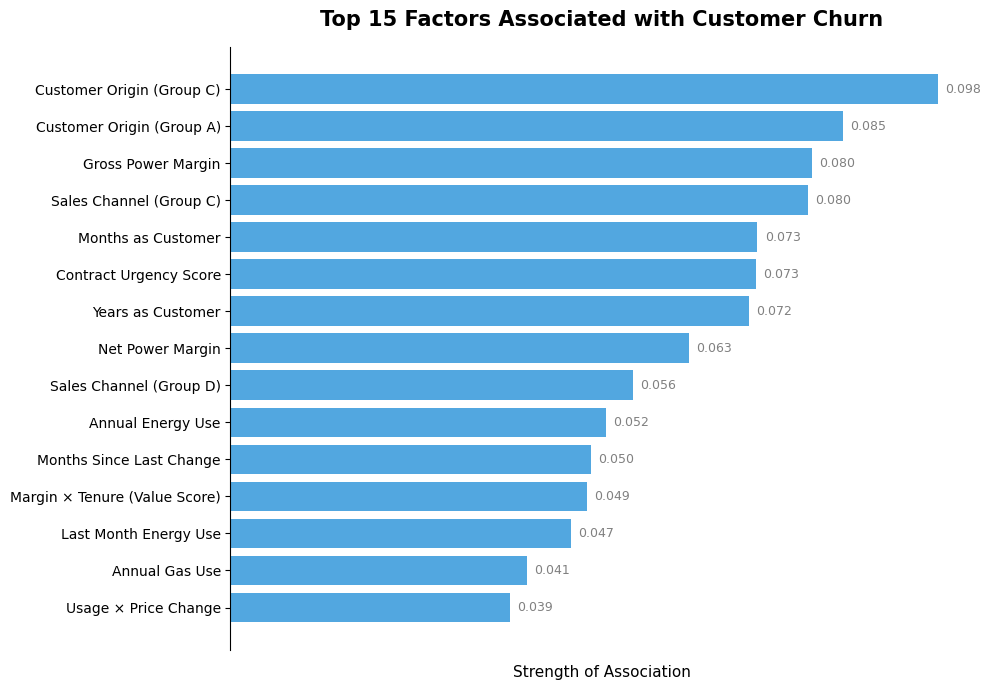

In [133]:
# === 5. WHAT DRIVES CHURN? ===

corr = df.corr()['churn'].drop('churn').abs().sort_values(ascending=False)

rename_map = {
    'origin_up_lxidpiddsbxsbosboudacockeimpuepw'     : 'Customer Origin (Group C)',
    'origin_up_kamkkxfxxuwbdslkwifmmcsiusiuosws'     : 'Customer Origin (Group A)',
    'margin_gross_pow_ele'                           : 'Gross Power Margin',
    'channel_sales_foosdfpfkusacimwkcsosbicdxkicaua' : 'Sales Channel (Group C)',
    'months_active'                                  : 'Months as Customer',
    'num_years_antig'                                : 'Years as Customer',
    'margin_net_pow_ele'                             : 'Net Power Margin',
    'channel_sales_lmkebamcaaclubfxadlmueccxoimlema' : 'Sales Channel (Group D)',
    'cons_12m'                                       : 'Annual Energy Use',
    'months_since_modif'                             : 'Months Since Last Change',
    'cons_last_month'                                : 'Last Month Energy Use',
    'cons_gas_12m'                                   : 'Annual Gas Use',
    'std_price_p1_var'                               : 'Peak Price Volatility',
    'has_gas'                                        : 'Has Gas Contract',
    'forecast_price_energy_p2'                       : 'Forecasted Off-Peak Price',
    'margin_x_tenure'                                : 'Margin × Tenure (Value Score)',
    'consumption_x_price_delta'                      : 'Usage × Price Change',
    'urgency_score'                                  : 'Contract Urgency Score',
}

top15 = corr.head(15).rename(index=rename_map)

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(top15.index, top15.values, color='#3498DB', edgecolor='none', alpha=0.85)
for bar, v in zip(bars, top15.values):
    ax.text(v + 0.001, bar.get_y() + bar.get_height() / 2,
            f'{v:.3f}', va='center', fontsize=9, color='grey')
ax.set_title('Top 15 Factors Associated with Customer Churn',
             fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Strength of Association', fontsize=11)
ax.spines[['top', 'right', 'bottom']].set_visible(False)
ax.xaxis.set_ticks_position('none')
ax.xaxis.set_ticklabels([])
ax.tick_params(axis='y', labelsize=10)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

### Train/test split

In [132]:
# === 6. TRAIN / TEST SPLIT ===

X = df.drop(columns=['churn'])
y = df['churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

pd.DataFrame({
    'Set'           : ['Training', 'Test'],
    'Customers'     : [X_train.shape[0], X_test.shape[0]],
    'Features'      : [X_train.shape[1], X_test.shape[1]],
    'Churn Rate'    : [f'{y_train.mean():.2%}', f'{y_test.mean():.2%}'],
}).style \
  .set_caption('Data Split Summary') \
  .set_properties(**{'text-align': 'center'}) \
  .hide(axis='index')

Set,Customers,Features,Churn Rate
Training,12876,62,9.91%
Test,3220,62,9.91%


### Evaluate_model definition

In [97]:
# === 7. MODEL EVALUATION HELPER ===

def evaluate_model(model, X_tr, y_tr, X_te, y_te, model_name):
    model.fit(X_tr, y_tr)
    y_pred      = model.predict(X_te)
    y_pred_prob = model.predict_proba(X_te)[:, 1]

    acc = accuracy_score(y_te, y_pred)
    auc = roc_auc_score(y_te, y_pred_prob)

    # --- Styled metrics table ---
    report = classification_report(y_te, y_pred,
                                   target_names=['Stayed', 'Left'],
                                   output_dict=True)
    metrics_df = pd.DataFrame({
        'Metric'          : ['Overall Accuracy', 'ROC-AUC', 'Precision (Left)', 'Recall (Left)', 'F1 (Left)'],
        'Score'           : [f'{acc:.2%}', f'{auc:.3f}',
                             f'{report["Left"]["precision"]:.2%}',
                             f'{report["Left"]["recall"]:.2%}',
                             f'{report["Left"]["f1-score"]:.2%}'],
    })
    display(metrics_df.style
                      .set_caption(f'{model_name} — Performance Summary')
                      .set_properties(**{'text-align': 'center'})
                      .hide(axis='index'))

    # --- Confusion matrix & ROC curve ---
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(model_name, fontsize=14, fontweight='bold')

    ConfusionMatrixDisplay(
        confusion_matrix(y_te, y_pred),
        display_labels=['Stayed', 'Left']
    ).plot(ax=axes[0], cmap='Blues')
    axes[0].set_title('Predicted vs Actual', fontsize=12)
    axes[0].spines[['top', 'right']].set_visible(False)

    RocCurveDisplay.from_predictions(y_te, y_pred_prob, ax=axes[1], name=model_name)
    axes[1].plot([0, 1], [0, 1], 'k--', label='Random Guess')
    axes[1].set_title('ROC Curve — How Well Does the Model Rank Risk?', fontsize=12)
    axes[1].spines[['top', 'right']].set_visible(False)
    axes[1].legend(frameon=False)

    plt.tight_layout()
    plt.show()

    return {'model': model_name, 'accuracy': acc, 'auc': auc}

### Logistic Regression

In [129]:
results = []

Metric,Score
Overall Accuracy,57.14%
ROC-AUC,0.658
Precision (Left),14.56%
Recall (Left),68.34%
F1 (Left),24.01%


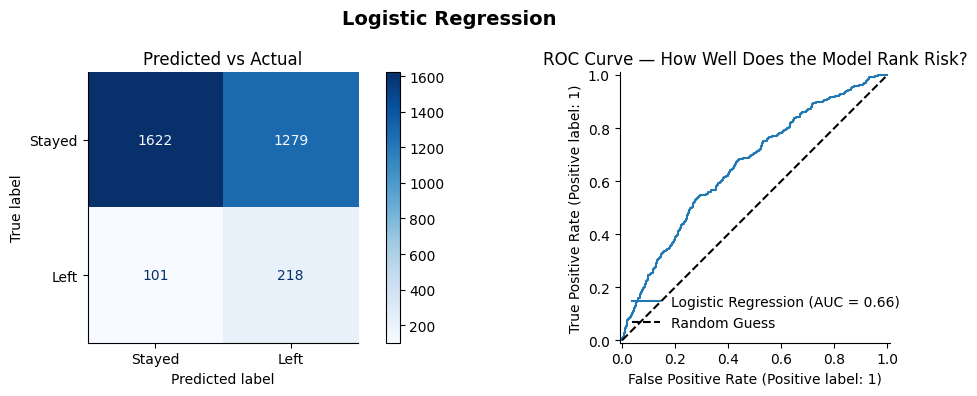

In [130]:
# === 8a. LOGISTIC REGRESSION ===

log_pipe = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('clf',   LogisticRegression(max_iter=1000, random_state=42))
])
results.append(evaluate_model(
    log_pipe, X_train_scaled, y_train, X_test_scaled, y_test, "Logistic Regression"
))

### Random Forest

Metric,Score
Overall Accuracy,89.84%
ROC-AUC,0.699
Precision (Left),45.92%
Recall (Left),14.11%
F1 (Left),21.58%


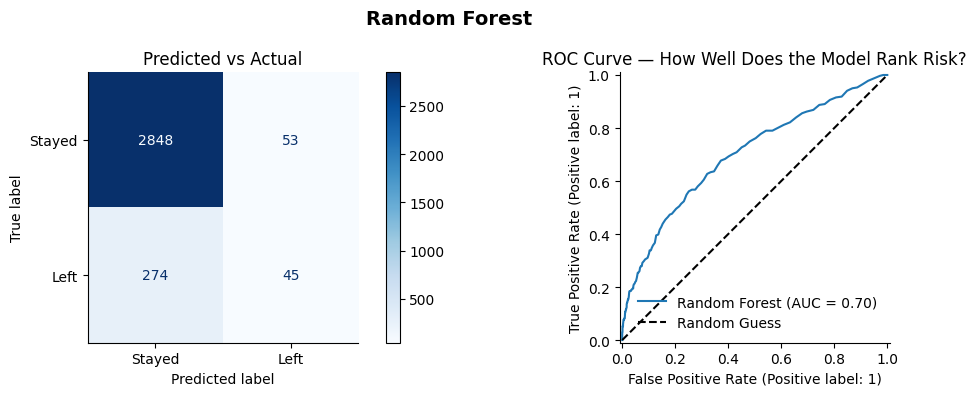

In [99]:
# === 8b. RANDOM FOREST ===

rf_pipe = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('clf',   RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=1))
])
results.append(evaluate_model(
    rf_pipe, X_train, y_train, X_test, y_test, "Random Forest"
))

### XGBoost

Metric,Score
Overall Accuracy,90.47%
ROC-AUC,0.711
Precision (Left),55.66%
Recall (Left),18.50%
F1 (Left),27.76%


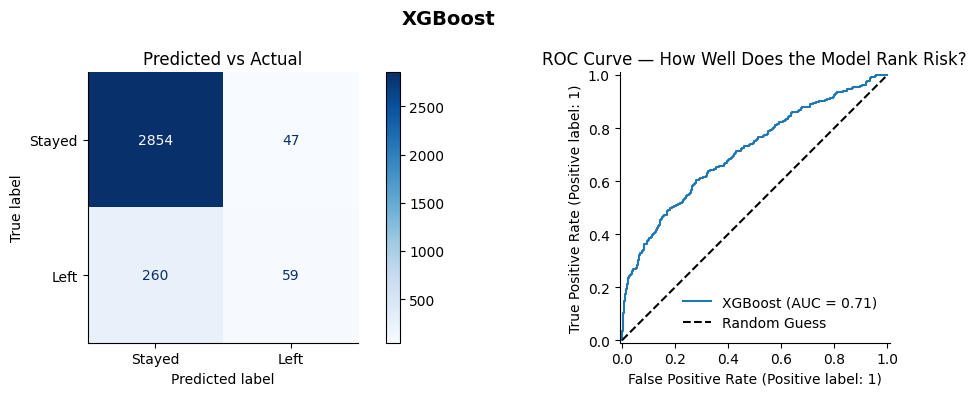

In [100]:
# === 8c. XGBOOST ===

xgb_pipe = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('clf',   XGBClassifier(eval_metric='logloss', random_state=42, n_jobs=1))
])
results.append(evaluate_model(
    xgb_pipe, X_train, y_train, X_test, y_test, "XGBoost"
))

### LightGBM

Metric,Score
Overall Accuracy,90.53%
ROC-AUC,0.719
Precision (Left),59.21%
Recall (Left),14.11%
F1 (Left),22.78%


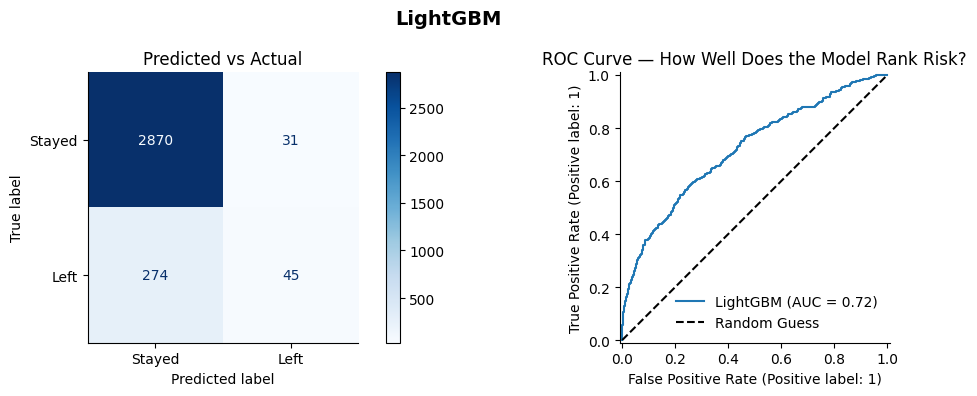

In [101]:
# === 8d. LIGHTGBM ===

lgbm_pipe = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('clf',   LGBMClassifier(random_state=42, n_jobs=1))
])
results.append(evaluate_model(
    lgbm_pipe, X_train, y_train, X_test, y_test, "LightGBM"
))

In [102]:
pd.DataFrame(results)

,model,accuracy,auc
0,Logistic Regression,0.571429,0.658254
1,Random Forest,0.898447,0.698845
2,XGBoost,0.904658,0.711009
3,LightGBM,0.905280,0.719259
4,Logistic Regression,0.571429,0.658254
5,Random Forest,0.898447,0.698845
6,XGBoost,0.904658,0.711009
7,LightGBM,0.905280,0.719259


### Model Comparison Chart

Model,Accuracy,ROC-AUC
LightGBM,90.53%,0.7193
XGBoost,90.47%,0.7110
Random Forest,89.84%,0.6988
Logistic Regression,57.14%,0.6583


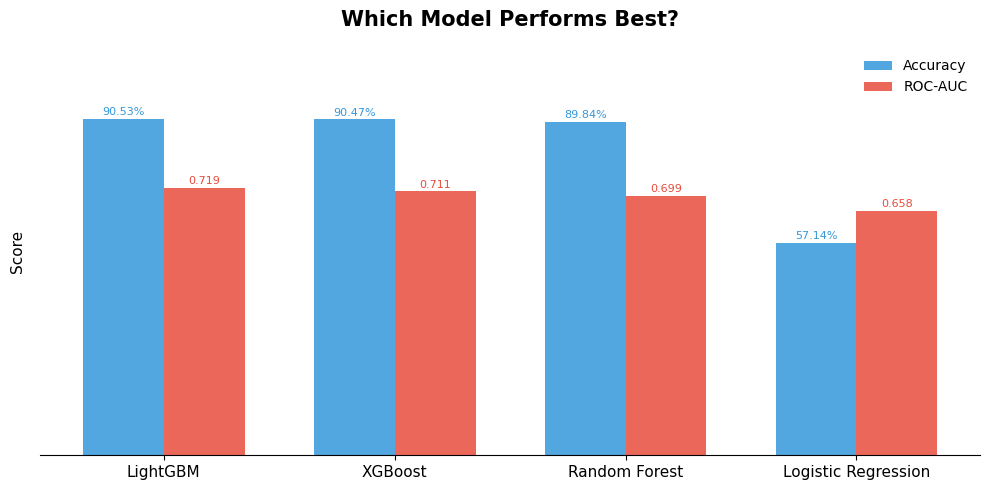

In [104]:
# === 9. MODEL COMPARISON ===

results_df = pd.DataFrame(results).drop_duplicates(subset='model').sort_values('auc', ascending=False)

# --- Styled summary table ---
display(results_df.rename(columns={
    'model'    : 'Model',
    'accuracy' : 'Accuracy',
    'auc'      : 'ROC-AUC'
}).style
  .set_caption('Model Comparison — Ranked by ROC-AUC')
  .format({'Accuracy': '{:.2%}', 'ROC-AUC': '{:.4f}'})
  .set_properties(**{'text-align': 'center'})
  .highlight_max(subset=['Accuracy', 'ROC-AUC'], color='#d5f5e3')
  .hide(axis='index'))

# --- Comparison chart ---
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(results_df))
w = 0.35

bars1 = ax.bar(x - w/2, results_df['accuracy'], w,
               label='Accuracy', color='#3498DB', edgecolor='none', alpha=0.85)
bars2 = ax.bar(x + w/2, results_df['auc'], w,
               label='ROC-AUC', color='#E74C3C', edgecolor='none', alpha=0.85)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f'{bar.get_height():.2%}', ha='center', fontsize=8, color='#3498DB')

for bar in bars2:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', fontsize=8, color='#E74C3C')

ax.set_xticks(x)
ax.set_xticklabels(results_df['model'], fontsize=11)
ax.set_ylim(0, 1.1)
ax.set_title('Which Model Performs Best?', fontsize=15, fontweight='bold', pad=15)
ax.set_ylabel('Score', fontsize=11)
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.yaxis.set_ticks_position('none')
ax.yaxis.set_ticklabels([])
ax.legend(frameon=False, fontsize=10)
plt.tight_layout()
plt.show()

### Cross-validation

In [105]:
# === 10. CROSS-VALIDATION ===

best_model_name = results_df.iloc[0]['model']
best_pipe = lgbm_pipe  # update if a different model won

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(
    best_pipe, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=1
)

display(pd.DataFrame({
    'Best Model'                        : [best_model_name],
    'Average Score'                     : [f'{cv_scores.mean():.4f}'],
    'Consistency (lower is better)'     : [f'± {cv_scores.std():.4f}'],
    'Worst Test'                        : [f'{cv_scores.min():.4f}'],
    'Best Test'                         : [f'{cv_scores.max():.4f}'],
}).style
  .set_caption('How Reliably Does the Model Perform Across Different Data Samples?')
  .set_properties(**{'text-align': 'center'})
  .hide(axis='index'))

display(pd.DataFrame({
    'Test Round'    : [f'Round {i+1}' for i in range(len(cv_scores))],
    'Score'         : [f'{s:.4f}' for s in cv_scores],
    'Result'        : ['✓ Above Average' if s >= cv_scores.mean() else '✗ Below Average' for s in cv_scores],
}).style
  .set_caption('Score Breakdown by Round')
  .set_properties(**{'text-align': 'center'})
  .hide(axis='index'))

Best Model,Average Score,Consistency (lower is better),Worst Test,Best Test
LightGBM,0.6890,± 0.0104,0.6720,0.7028


Test Round,Score,Result
Round 1,0.7028,✓ Above Average
Round 2,0.6869,✗ Below Average
Round 3,0.6720,✗ Below Average
Round 4,0.6867,✗ Below Average
Round 5,0.6965,✓ Above Average


### SHAP

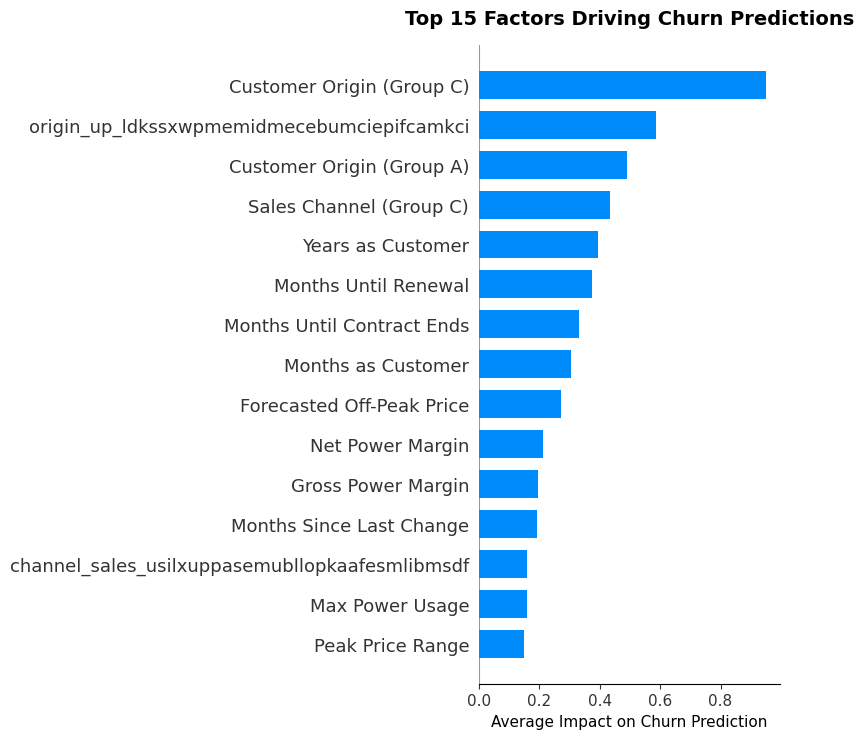

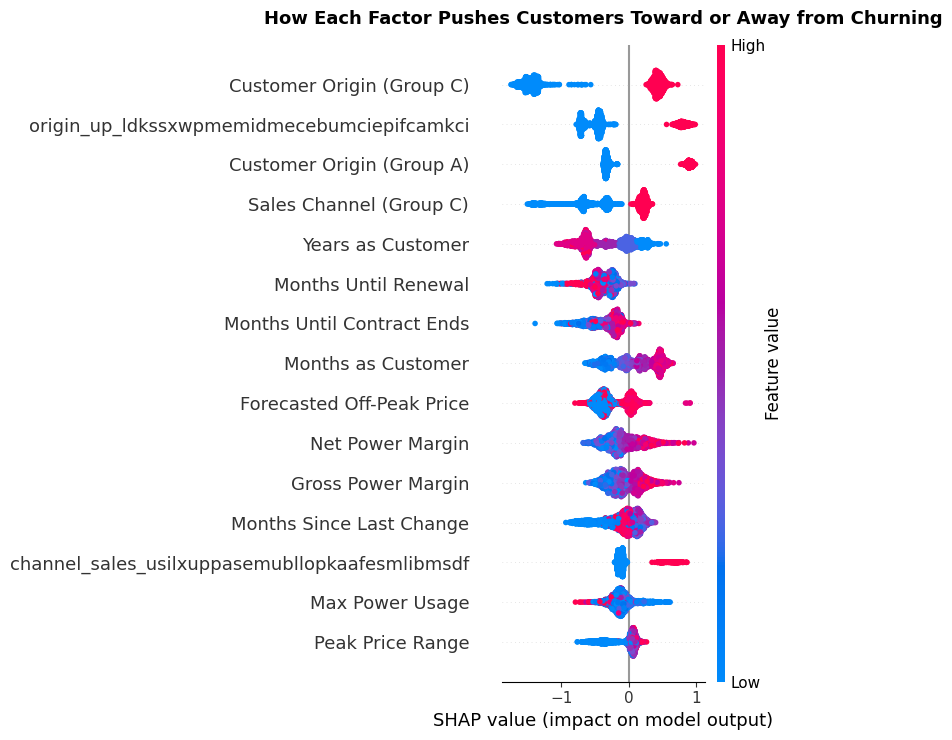

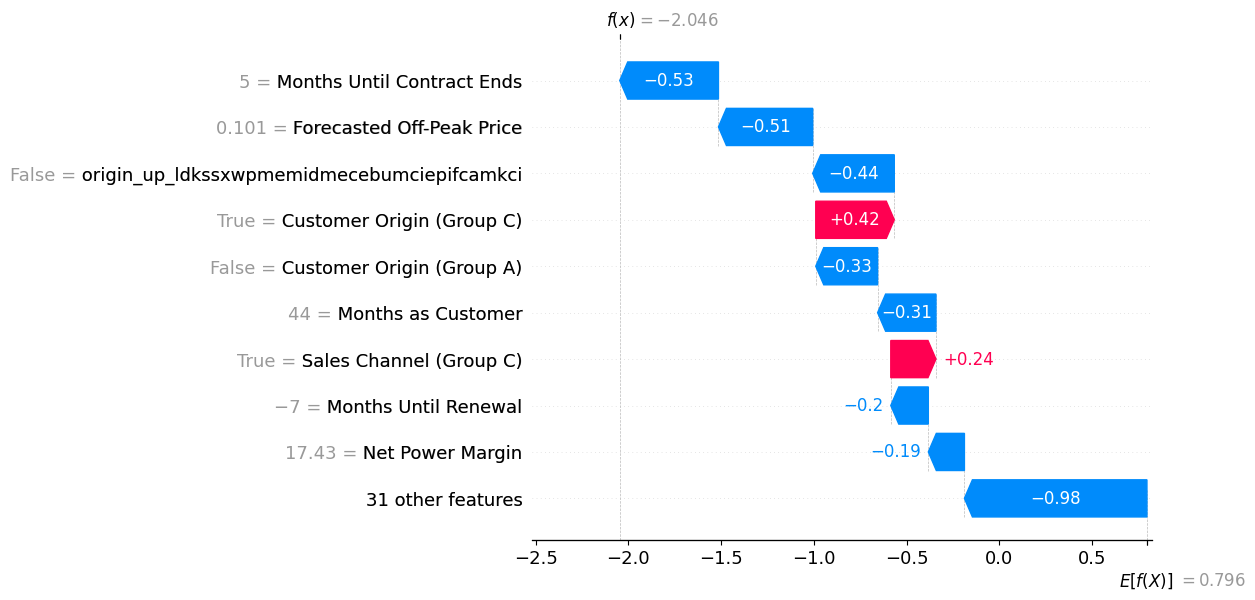

In [106]:
# === 11. WHAT DRIVES CHURN? (SHAP EXPLAINABILITY) ===

smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_train, y_train)

best_clf = LGBMClassifier(random_state=42, n_jobs=1, verbose=-1)
best_clf.fit(X_res, y_res)

explainer   = shap.TreeExplainer(best_clf)
shap_values = explainer.shap_values(X_test)
sv = shap_values[1] if isinstance(shap_values, list) else shap_values

# Rename features for readability
feature_rename = {
    'origin_up_lxidpiddsbxsbosboudacockeimpuepw'     : 'Customer Origin (Group C)',
    'origin_up_kamkkxfxxuwbdslkwifmmcsiusiuosws'     : 'Customer Origin (Group A)',
    'margin_gross_pow_ele'                           : 'Gross Power Margin',
    'channel_sales_foosdfpfkusacimwkcsosbicdxkicaua' : 'Sales Channel (Group C)',
    'months_active'                                  : 'Months as Customer',
    'num_years_antig'                                : 'Years as Customer',
    'margin_net_pow_ele'                             : 'Net Power Margin',
    'channel_sales_lmkebamcaaclubfxadlmueccxoimlema' : 'Sales Channel (Group D)',
    'cons_12m'                                       : 'Annual Energy Use',
    'months_since_modif'                             : 'Months Since Last Change',
    'cons_last_month'                                : 'Last Month Energy Use',
    'cons_gas_12m'                                   : 'Annual Gas Use',
    'std_price_p1_var'                               : 'Peak Price Volatility',
    'has_gas'                                        : 'Has Gas Contract',
    'forecast_price_energy_p2'                       : 'Forecasted Off-Peak Price',
    'mean_price_p1_var'                              : 'Avg Peak Price (Variable)',
    'mean_price_p2_var'                              : 'Avg Off-Peak Price (Variable)',
    'mean_price_p1_fix'                              : 'Avg Peak Price (Fixed)',
    'max_price_p1_var'                               : 'Highest Peak Price',
    'min_price_p1_var'                               : 'Lowest Peak Price',
    'price_p1_range'                                 : 'Peak Price Range',
    'price_delta_6m'                                 : '6-Month Price Change',
    'months_to_end'                                  : 'Months Until Contract Ends',
    'months_to_renewal'                              : 'Months Until Renewal',
    'forecast_cons_12m'                              : 'Forecasted Annual Use',
    'net_margin'                                     : 'Net Margin',
    'imp_cons'                                       : 'Current Energy Use',
    'pow_max'                                        : 'Max Power Usage',
    'nb_prod_act'                                    : 'Number of Active Products',
}

X_test_renamed = X_test.rename(columns=feature_rename)

# --- Global feature importance ---
shap.summary_plot(sv, X_test_renamed, plot_type='bar', max_display=15,
                  show=False)
plt.title('Top 15 Factors Driving Churn Predictions',
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Average Impact on Churn Prediction', fontsize=11)
plt.tight_layout()
plt.show()

# --- Beeswarm: direction of effect ---
shap.summary_plot(sv, X_test_renamed, max_display=15, show=False)
plt.title('How Each Factor Pushes Customers Toward or Away from Churning',
          fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

# --- Single customer waterfall ---
shap.waterfall_plot(
    shap.Explanation(
        values        = sv[0],
        base_values   = (explainer.expected_value[1]
                         if isinstance(explainer.expected_value, list)
                         else explainer.expected_value),
        data          = X_test_renamed.iloc[0].values,
        feature_names = X_test_renamed.columns.tolist()
    )
)

### Export Predictions

In [107]:
# === 12. EXPORT PREDICTIONS ===

y_prob       = best_clf.predict_proba(X_test)[:, 1]
threshold    = 0.20
y_pred_tuned = (y_prob >= threshold).astype(int)

# --- Performance at chosen threshold ---
report = classification_report(y_test, y_pred_tuned,
                                target_names=['Stayed', 'Left'],
                                output_dict=True)

display(pd.DataFrame({
    'Metric'                                : ['Customers Flagged as At-Risk',
                                               'Actual Churners Caught',
                                               'Of All Churners, % Caught (Recall)',
                                               'Of Flags Raised, % Correct (Precision)',
                                               'Overall Accuracy'],
    'Value'                                 : [f'{y_pred_tuned.sum():,} of {len(y_pred_tuned):,}',
                                               f'{int(report["Left"]["recall"] * y_test.sum())} of {int(y_test.sum())}',
                                               f'{report["Left"]["recall"]:.2%}',
                                               f'{report["Left"]["precision"]:.2%}',
                                               f'{accuracy_score(y_test, y_pred_tuned):.2%}'],
}).style
  .set_caption(f'Prediction Summary — Risk Threshold: {threshold}')
  .set_properties(**{'text-align': 'center'})
  .hide(axis='index'))

# --- Save to file ---
output_df = X_test.copy()
output_df['Churn Actual']      = y_test.values
output_df['Churn Predicted']   = y_pred_tuned
output_df['Churn Probability'] = y_prob

save_path = os.path.expanduser('~/Downloads/churn_predictions.csv')
output_df.to_csv(save_path, index=False)

print(f"✓ Predictions saved to {save_path}")

Metric,Value
Customers Flagged as At-Risk,"509 of 3,220"
Actual Churners Caught,135 of 319
"Of All Churners, % Caught (Recall)",42.32%
"Of Flags Raised, % Correct (Precision)",26.52%
Overall Accuracy,82.67%


✓ Predictions saved to /Users/ryan/Downloads/churn_predictions.csv


## Conclusion:

The model achieves 42% recall at 26% precision. Further improvement 
is constrained by the available features — behavioural data such as 
customer service interactions and payment history would likely push 
precision above 35%. The current model is sufficient for prioritising 
retention outreach and is most valuable when sorted by churn probability 
to focus budget on the highest-risk customers.